# 🧠 AI Strategic Insight Discovery System
### MATS Stream — Jeff Alstott

**Goal:** Use frontier AI to derive non-obvious strategic implications from scientific and technical knowledge.

**Pipeline:**
1. Ingest scientific papers (arXiv)
2. Build a knowledge graph
3. Retrieve + explore cross-domain context
4. Generate hypotheses (multi-agent)
5. Debate + falsify hypotheses
6. Abstract into strategic insights
7. Evaluate & score

**LLM:** Groq API (free tier — LLaMA 3.1 70B)  
**Vector DB:** ChromaDB (in-memory)  
**Graph:** NetworkX  
**Papers:** arXiv API

---
## STAGE 0 — Setup & Installation

In [1]:
# Install all dependencies
!pip install -q groq chromadb sentence-transformers networkx arxiv PyMuPDF tqdm matplotlib python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 27.4 MB/s eta 0:00:00
   ━━

In [2]:
import os
import json
import time
import re
import textwrap
import warnings
from collections import defaultdict
from typing import List, Dict, Any, Optional, Tuple

import networkx as nx
import matplotlib.pyplot as plt
import arxiv
import chromadb
from sentence_transformers import SentenceTransformer
from groq import Groq
from tqdm import tqdm

warnings.filterwarnings('ignore')
print('✅ All imports successful')

✅ All imports successful


In [6]:
# ─────────────────────────────────────────────
# 🔑 API KEY SETUP
# Get your FREE Groq API key at: https://console.groq.com
# ─────────────────────────────────────────────

from google.colab import userdata

# Option A: Use Colab Secrets (recommended — click the 🔑 key icon on the left sidebar)
try:
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    print('✅ Loaded API key from Colab Secrets')
except Exception:
    # Option B: Paste directly (less secure)
    GROQ_API_KEY = "your-groq-api-key-here"  # ← REPLACE THIS
    print('⚠️  Using hardcoded API key — prefer Colab Secrets')

client = Groq(api_key=GROQ_API_KEY)
print('✅ Groq client initialized')

✅ Loaded API key from Colab Secrets
✅ Groq client initialized


In [7]:
# ─────────────────────────────────────────────
# ⚙️ GLOBAL CONFIGURATION
# ─────────────────────────────────────────────

CONFIG = {
    # LLM
    "model": "llama-3.1-70b-versatile",   # Free on Groq; swap to "llama3-8b-8192" if rate-limited
    "temperature_creative": 0.85,
    "temperature_analytical": 0.3,
    "max_tokens": 1500,

    # Retrieval
    "embedding_model": "all-MiniLM-L6-v2",
    "chunk_size": 400,                    # tokens per chunk
    "chunk_overlap": 50,
    "top_k_retrieval": 5,

    # Graph
    "max_graph_neighbors": 3,

    # Pipeline
    "num_papers": 10,                     # papers to ingest per query (keep ≤15 on free Colab)
    "num_hypotheses": 5,                  # hypotheses to generate
    "debate_rounds": 2,                   # debate rounds per hypothesis
    "falsification_threshold": 0.35,      # discard if robustness < this

    # Rate limiting (Groq free tier)
    "sleep_between_calls": 1.5,           # seconds
}

print('✅ Configuration loaded')
print(json.dumps(CONFIG, indent=2))

✅ Configuration loaded
{
  "model": "llama-3.1-70b-versatile",
  "temperature_creative": 0.85,
  "temperature_analytical": 0.3,
  "max_tokens": 1500,
  "embedding_model": "all-MiniLM-L6-v2",
  "chunk_size": 400,
  "chunk_overlap": 50,
  "top_k_retrieval": 5,
  "max_graph_neighbors": 3,
  "num_papers": 10,
  "num_hypotheses": 5,
  "debate_rounds": 2,
  "falsification_threshold": 0.35,
  "sleep_between_calls": 1.5
}


---
## STAGE 1 — LLM Wrapper

In [9]:
CONFIG["model"] = "llama-3.3-70b-versatile"
client = Groq(api_key=GROQ_API_KEY)
print("✅ Model updated")

✅ Model updated


In [10]:
def query_llm(
    prompt: str,
    system: str = "You are an expert scientific strategist.",
    temperature: float = None,
    max_tokens: int = None,
    retries: int = 3
) -> str:
    """
    Central LLM call wrapper with retry logic and rate limiting.
    """
    temp = temperature if temperature is not None else CONFIG["temperature_creative"]
    max_tok = max_tokens if max_tokens is not None else CONFIG["max_tokens"]

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=CONFIG["model"],
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user", "content": prompt}
                ],
                temperature=temp,
                max_tokens=max_tok
            )
            time.sleep(CONFIG["sleep_between_calls"])
            return response.choices[0].message.content.strip()
        except Exception as e:
            wait = (attempt + 1) * 5
            print(f'  ⚠️  LLM error (attempt {attempt+1}): {e}. Retrying in {wait}s...')
            time.sleep(wait)

    return "[LLM call failed after retries]"


# Quick test
test = query_llm("Say 'System online' and nothing else.")
print(f'LLM test: {test}')

LLM test: System online


---
## STAGE 2 — Data Ingestion (arXiv)

In [11]:
def fetch_arxiv_papers(query: str, max_results: int = None) -> List[Dict]:
    """
    Fetch papers from arXiv using the arxiv Python client.
    Returns list of dicts with title, abstract, authors, year, arxiv_id.
    """
    max_results = max_results or CONFIG["num_papers"]
    print(f'  📡 Fetching {max_results} papers for: "{query}"')

    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance
    )

    papers = []
    for result in search.results():
        papers.append({
            "arxiv_id": result.entry_id.split("/")[-1],
            "title": result.title,
            "abstract": result.summary.replace("\n", " "),
            "authors": [str(a) for a in result.authors[:3]],
            "year": result.published.year,
            "categories": result.categories,
            "url": result.entry_id
        })

    print(f'  ✅ Fetched {len(papers)} papers')
    return papers


def chunk_text(text: str, chunk_size: int = None, overlap: int = None) -> List[str]:
    """
    Split text into overlapping word-based chunks.
    """
    chunk_size = chunk_size or CONFIG["chunk_size"]
    overlap = overlap or CONFIG["chunk_overlap"]

    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        start += chunk_size - overlap
    return chunks


def papers_to_chunks(papers: List[Dict]) -> List[Dict]:
    """
    Convert papers into chunks ready for embedding.
    Each chunk carries metadata (title, year, arxiv_id, categories).
    """
    all_chunks = []
    for paper in papers:
        full_text = f"{paper['title']}. {paper['abstract']}"
        chunks = chunk_text(full_text)
        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "text": chunk,
                "metadata": {
                    "arxiv_id": paper["arxiv_id"],
                    "title": paper["title"],
                    "year": str(paper["year"]),
                    "categories": ",".join(paper["categories"][:2]),
                    "chunk_index": str(i)
                },
                "id": f"{paper['arxiv_id']}_chunk_{i}"
            })
    return all_chunks


print('✅ Ingestion functions defined')

✅ Ingestion functions defined


---
## STAGE 3 — Vector Database (ChromaDB)

In [12]:
class VectorStore:
    """
    ChromaDB-backed vector store with sentence-transformer embeddings.
    Works fully in-memory on free Colab.
    """

    def __init__(self, collection_name: str = "scientific_knowledge"):
        print(f'  🗄️  Initializing VectorStore: {collection_name}')
        self.embed_model = SentenceTransformer(CONFIG["embedding_model"])
        self.chroma_client = chromadb.Client()  # in-memory
        # Delete collection if it exists (for re-runs)
        try:
            self.chroma_client.delete_collection(collection_name)
        except Exception:
            pass
        self.collection = self.chroma_client.create_collection(
            name=collection_name,
            metadata={"hnsw:space": "cosine"}
        )
        print('  ✅ VectorStore ready')

    def add_chunks(self, chunks: List[Dict]):
        """Embed and store chunks in batches."""
        batch_size = 64
        print(f'  📥 Adding {len(chunks)} chunks to vector store...')
        for i in range(0, len(chunks), batch_size):
            batch = chunks[i:i + batch_size]
            texts = [c["text"] for c in batch]
            ids = [c["id"] for c in batch]
            metadatas = [c["metadata"] for c in batch]
            embeddings = self.embed_model.encode(texts, show_progress_bar=False).tolist()
            self.collection.add(
                documents=texts,
                embeddings=embeddings,
                metadatas=metadatas,
                ids=ids
            )
        print(f'  ✅ Vector store now has {self.collection.count()} chunks')

    def retrieve(self, query: str, top_k: int = None) -> List[Dict]:
        """Semantic search over stored chunks."""
        top_k = top_k or CONFIG["top_k_retrieval"]
        query_embedding = self.embed_model.encode([query]).tolist()
        results = self.collection.query(
            query_embeddings=query_embedding,
            n_results=min(top_k, self.collection.count())
        )
        retrieved = []
        for doc, meta, dist in zip(
            results["documents"][0],
            results["metadatas"][0],
            results["distances"][0]
        ):
            retrieved.append({
                "text": doc,
                "metadata": meta,
                "relevance_score": round(1 - dist, 3)
            })
        return retrieved


print('✅ VectorStore class defined')

✅ VectorStore class defined


---
## STAGE 4 — Knowledge Graph Construction

In [13]:
class KnowledgeGraph:
    """
    NetworkX-based knowledge graph.
    Nodes = entities (technologies, concepts, domains).
    Edges = relationships extracted by LLM.
    """

    def __init__(self):
        self.G = nx.DiGraph()
        self.entity_to_papers = defaultdict(list)
        print('✅ Knowledge graph initialized')

    def extract_entities_and_relations(self, text: str, paper_title: str) -> Dict:
        """
        Use LLM to extract entities and relationships from a text chunk.
        Returns dict with 'entities' and 'relations'.
        """
        prompt = f"""From the following scientific text, extract:
1. Key entities (technologies, methods, concepts, organisms, materials). List up to 6.
2. Relationships between them.

Text: {text[:800]}

Respond ONLY in this exact JSON format (no extra text, no markdown):
{{
  "entities": ["entity1", "entity2", "entity3"],
  "relations": [
    {{"from": "entity1", "relation": "enables", "to": "entity2"}},
    {{"from": "entity2", "relation": "reduces", "to": "entity3"}}
  ]
}}"""

        raw = query_llm(
            prompt,
            system="You are a precise scientific knowledge extractor. Return only valid JSON.",
            temperature=0.1,
            max_tokens=500
        )

        try:
            # Strip possible markdown fences
            raw = re.sub(r"```json|```", "", raw).strip()
            return json.loads(raw)
        except Exception:
            return {"entities": [], "relations": []}

    def build_from_papers(self, papers: List[Dict], sample_per_paper: int = 1):
        """
        Build the graph by extracting entities/relations from paper abstracts.
        sample_per_paper: how many chunks per paper to process (keep low for speed).
        """
        print(f'  🔨 Building knowledge graph from {len(papers)} papers...')
        for paper in tqdm(papers, desc='Building graph'):
            text = paper["abstract"]
            extracted = self.extract_entities_and_relations(text, paper["title"])

            # Add entities as nodes
            for entity in extracted.get("entities", []):
                entity = entity.strip().lower()
                if not self.G.has_node(entity):
                    self.G.add_node(entity, papers=[], categories=[])
                self.G.nodes[entity]["papers"].append(paper["arxiv_id"])
                self.G.nodes[entity]["categories"].extend(paper["categories"][:1])
                self.entity_to_papers[entity].append(paper["title"])

            # Add relations as edges
            for rel in extracted.get("relations", []):
                src = rel.get("from", "").strip().lower()
                tgt = rel.get("to", "").strip().lower()
                relation = rel.get("relation", "relates_to").strip()
                if src and tgt and src != tgt:
                    if not self.G.has_node(src):
                        self.G.add_node(src, papers=[], categories=[])
                    if not self.G.has_node(tgt):
                        self.G.add_node(tgt, papers=[], categories=[])
                    self.G.add_edge(src, tgt, relation=relation, weight=1)

        print(f'  ✅ Graph: {self.G.number_of_nodes()} nodes, {self.G.number_of_edges()} edges')

    def get_neighborhood(self, entity: str, depth: int = 2) -> List[str]:
        """
        Get neighbors of an entity up to a given depth.
        Returns list of (entity, relation, neighbor) strings.
        """
        entity = entity.lower().strip()
        if entity not in self.G:
            return []

        context_edges = []
        visited = {entity}
        frontier = [entity]

        for _ in range(depth):
            next_frontier = []
            for node in frontier:
                for neighbor in list(self.G.successors(node)) + list(self.G.predecessors(node)):
                    if neighbor not in visited:
                        visited.add(neighbor)
                        next_frontier.append(neighbor)
                        rel = self.G.edges.get((node, neighbor), {}).get("relation", "relates_to")
                        context_edges.append(f"{node} --[{rel}]--> {neighbor}")
            frontier = next_frontier[:CONFIG["max_graph_neighbors"] * 2]

        return context_edges[:15]  # cap for prompt length

    def get_cross_domain_bridges(self) -> List[str]:
        """
        Find nodes that connect different scientific categories — key for cross-domain insight.
        """
        bridges = []
        for node in self.G.nodes():
            cats = list(set(self.G.nodes[node].get("categories", [])))
            if len(cats) >= 2:
                bridges.append((node, cats))
        return bridges[:10]

    def visualize(self, max_nodes: int = 40):
        """Quick visualization of the graph."""
        subgraph_nodes = list(self.G.nodes())[:max_nodes]
        sub = self.G.subgraph(subgraph_nodes)

        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(sub, seed=42, k=1.5)
        degrees = dict(sub.degree())
        node_size = [300 + degrees.get(n, 0) * 200 for n in sub.nodes()]

        nx.draw_networkx_nodes(sub, pos, node_size=node_size,
                               node_color='steelblue', alpha=0.8)
        nx.draw_networkx_edges(sub, pos, alpha=0.4, arrows=True,
                               arrowsize=15, edge_color='gray')
        nx.draw_networkx_labels(sub, pos, font_size=7)

        edge_labels = {(u, v): d.get("relation", "")[:12]
                      for u, v, d in sub.edges(data=True)}
        nx.draw_networkx_edge_labels(sub, pos, edge_labels, font_size=6)

        plt.title("Knowledge Graph (sample)", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        print(f'Full graph: {self.G.number_of_nodes()} nodes, {self.G.number_of_edges()} edges')


print('✅ KnowledgeGraph class defined')

✅ KnowledgeGraph class defined


---
## STAGE 5 — Hypothesis Generation

In [14]:
class HypothesisGenerator:
    """
    Generates diverse, non-obvious strategic hypotheses from
    retrieved scientific context + graph neighborhood.
    """

    DOMAIN_PAIRS = [
        ("geopolitics", "supply chains"),
        ("labor markets", "national security"),
        ("public health", "economic power"),
        ("military capability", "civil infrastructure"),
        ("environmental policy", "technological competition"),
    ]

    def generate(
        self,
        topic: str,
        retrieved_chunks: List[Dict],
        graph_context: List[str],
        num_hypotheses: int = None
    ) -> List[Dict]:

        num_hypotheses = num_hypotheses or CONFIG["num_hypotheses"]

        # Build context string
        context_text = "\n\n".join([
            f"[Source: {c['metadata']['title']} ({c['metadata']['year']})]\n{c['text']}"
            for c in retrieved_chunks[:5]
        ])

        graph_text = "\n".join(graph_context[:10]) if graph_context else "(No graph context)"

        # Domain diversity constraint
        domain_examples = "\n".join([
            f"  - Link '{a}' to '{b}'" for a, b in self.DOMAIN_PAIRS
        ])

        prompt = f"""You are a strategic foresight expert analyzing scientific advances for hidden implications.

TOPIC: {topic}

SCIENTIFIC CONTEXT:
{context_text}

KNOWLEDGE GRAPH RELATIONSHIPS:
{graph_text}

TASK: Generate exactly {num_hypotheses} non-obvious strategic hypotheses.

Requirements for each hypothesis:
- Must involve cross-domain reasoning (e.g., science → geopolitics, biology → economics)
- Must be non-trivial — avoid obvious/surface-level observations
- Must be falsifiable (i.e., could in principle be proven wrong)
- Each hypothesis should involve DIFFERENT domain pairs, such as:
{domain_examples}

Respond ONLY in this exact JSON format (no markdown, no extra text):
[
  {{
    "id": 1,
    "hypothesis": "[One clear, specific statement]",
    "domain_from": "[scientific domain]",
    "domain_to": "[strategic domain]",
    "reasoning": "[2-3 sentences explaining the causal chain]",
    "time_horizon": "[5-10 years / 10-20 years / 20+ years]"
  }}
]"""

        raw = query_llm(
            prompt,
            system="You are a precise strategic foresight analyst. Return only valid JSON arrays.",
            temperature=CONFIG["temperature_creative"]
        )

        try:
            raw = re.sub(r"```json|```", "", raw).strip()
            hypotheses = json.loads(raw)
            print(f'  ✅ Generated {len(hypotheses)} hypotheses')
            return hypotheses
        except Exception as e:
            print(f'  ⚠️  JSON parse failed: {e}\n  Raw: {raw[:300]}')
            return []


print('✅ HypothesisGenerator defined')

✅ HypothesisGenerator defined


---
## STAGE 6 — Multi-Agent Debate System

In [15]:
class DebateAgent:
    """A single debating agent with a fixed role and persona."""

    PERSONAS = {
        "proposer": {
            "system": "You are an optimistic futurist and strategic analyst. Your role is to build the strongest possible case FOR a hypothesis, identifying supporting evidence and mechanisms.",
            "instruction": "Argue WHY this hypothesis is valid and likely. Identify supporting evidence and causal mechanisms. Be specific."
        },
        "skeptic": {
            "system": "You are a rigorous scientific skeptic and policy realist. Your role is to find flaws, weak assumptions, and alternative explanations that UNDERMINE the hypothesis.",
            "instruction": "Identify the 3 strongest weaknesses in this hypothesis. What assumptions does it rely on? What could make it wrong? Be ruthlessly critical."
        },
        "domain_expert": {
            "system": "You are a cross-disciplinary expert in both science and geopolitics. Your role is to add real-world constraints, historical analogies, and feasibility assessments.",
            "instruction": "Assess feasibility using historical analogies and real-world constraints. What conditions need to hold for this to occur? What would accelerate or delay it?"
        }
    }

    def __init__(self, role: str):
        assert role in self.PERSONAS, f"Unknown role: {role}"
        self.role = role
        self.persona = self.PERSONAS[role]

    def respond(
        self,
        hypothesis: str,
        context: str,
        prior_arguments: str = ""
    ) -> str:

        prior_section = f"\n\nPRIOR ARGUMENTS IN THIS DEBATE:\n{prior_arguments}" if prior_arguments else ""

        prompt = f"""HYPOTHESIS UNDER DEBATE:
"{hypothesis}"

RELEVANT SCIENTIFIC CONTEXT:
{context[:1200]}
{prior_section}

YOUR ROLE: {self.persona['instruction']}

Provide a focused, 150-200 word response. Be specific and analytical."""

        return query_llm(
            prompt,
            system=self.persona["system"],
            temperature=CONFIG["temperature_analytical"]
        )


class DebateOrchestrator:
    """Runs structured multi-agent debates and produces consensus verdicts."""

    def __init__(self):
        self.proposer = DebateAgent("proposer")
        self.skeptic = DebateAgent("skeptic")
        self.expert = DebateAgent("domain_expert")

    def run_debate(
        self,
        hypothesis_dict: Dict,
        context: str,
        rounds: int = None
    ) -> Dict:

        rounds = rounds or CONFIG["debate_rounds"]
        hypothesis = hypothesis_dict["hypothesis"]
        debate_log = []
        prior_arguments = ""

        print(f'    💬 Debating: "{hypothesis[:80]}..."')

        for round_num in range(1, rounds + 1):
            print(f'      Round {round_num}/{rounds}...')

            proposer_arg = self.proposer.respond(hypothesis, context, prior_arguments)
            skeptic_arg = self.skeptic.respond(hypothesis, context, prior_arguments + f"\n[Proposer]: {proposer_arg}")
            expert_arg = self.expert.respond(hypothesis, context, prior_arguments + f"\n[Proposer]: {proposer_arg}\n[Skeptic]: {skeptic_arg}")

            round_log = {
                "round": round_num,
                "proposer": proposer_arg,
                "skeptic": skeptic_arg,
                "domain_expert": expert_arg
            }
            debate_log.append(round_log)

            prior_arguments += f"\n\n--- Round {round_num} ---"
            prior_arguments += f"\n[Proposer]: {proposer_arg[:300]}"
            prior_arguments += f"\n[Skeptic]: {skeptic_arg[:300]}"
            prior_arguments += f"\n[Expert]: {expert_arg[:300]}"

        # Generate synthesis verdict
        verdict = self._synthesize(hypothesis, debate_log)

        return {
            "hypothesis": hypothesis_dict,
            "debate_log": debate_log,
            "verdict": verdict
        }

    def _synthesize(self, hypothesis: str, debate_log: List[Dict]) -> Dict:
        """Synthesize debate into a verdict with confidence score."""
        all_args = ""
        for r in debate_log:
            all_args += f"\nRound {r['round']}:"
            all_args += f"\n  Proposer: {r['proposer'][:200]}"
            all_args += f"\n  Skeptic: {r['skeptic'][:200]}"
            all_args += f"\n  Expert: {r['domain_expert'][:200]}"

        prompt = f"""You have observed a structured debate about the following strategic hypothesis:

HYPOTHESIS: "{hypothesis}"

DEBATE TRANSCRIPT (summary):
{all_args[:2000]}

As a neutral judge, provide a synthesis verdict.

Respond ONLY in this exact JSON format (no markdown):
{{
  "overall_validity": "strong/moderate/weak/rejected",
  "confidence_score": 0.0,
  "key_supporting_points": ["point1", "point2"],
  "key_weaknesses": ["weakness1", "weakness2"],
  "refined_hypothesis": "[A refined, more precise version of the hypothesis based on the debate]",
  "conditions_required": ["condition1", "condition2"]
}}

Set confidence_score between 0.0 and 1.0 based on the balance of arguments."""

        raw = query_llm(
            prompt,
            system="You are a neutral synthesis judge. Return only valid JSON.",
            temperature=0.2
        )

        try:
            raw = re.sub(r"```json|```", "", raw).strip()
            return json.loads(raw)
        except Exception:
            return {"overall_validity": "unknown", "confidence_score": 0.5,
                   "key_supporting_points": [], "key_weaknesses": [],
                   "refined_hypothesis": hypothesis, "conditions_required": []}


print('✅ Debate system defined')

✅ Debate system defined


---
## STAGE 7 — Falsification Loop

In [16]:
class FalsificationEngine:
    """
    Actively seeks counter-evidence to test hypothesis robustness.
    Hypotheses that survive falsification are more credible.
    """

    def __init__(self, vector_store: VectorStore):
        self.vs = vector_store

    def generate_counter_queries(self, hypothesis: str) -> List[str]:
        """Generate queries designed to find contradicting evidence."""
        prompt = f"""For the following hypothesis, generate 3 search queries that would find CONTRADICTORY evidence:

Hypothesis: "{hypothesis}"

Generate queries that would surface:
1. Evidence the premise is wrong
2. Evidence the mechanism doesn't work as assumed
3. Evidence of strong counterfactuals

Return ONLY a JSON array of 3 strings. No markdown, no explanation.
Example: ["query1", "query2", "query3"]"""

        raw = query_llm(
            prompt,
            system="You are a falsification expert. Return only a JSON array.",
            temperature=0.3,
            max_tokens=200
        )
        try:
            raw = re.sub(r"```json|```", "", raw).strip()
            return json.loads(raw)
        except Exception:
            return [f"evidence against {hypothesis[:50]}"]

    def test_hypothesis(
        self,
        hypothesis: str,
        verdict: Dict
    ) -> Dict:
        """Run falsification test and return updated robustness score."""
        print(f'    🔬 Falsifying: "{hypothesis[:70]}..."')

        # Generate counter-evidence queries
        counter_queries = self.generate_counter_queries(hypothesis)

        # Retrieve contradicting evidence
        counter_evidence = []
        for q in counter_queries:
            results = self.vs.retrieve(q, top_k=2)
            counter_evidence.extend(results)

        counter_text = "\n".join([c["text"][:200] for c in counter_evidence[:4]])

        if not counter_text:
            counter_text = "No specific counter-evidence found in corpus."

        # Evaluate under counter-evidence
        prompt = f"""Evaluate whether the following hypothesis survives this counter-evidence.

HYPOTHESIS: "{hypothesis}"

ORIGINAL CONFIDENCE: {verdict.get('confidence_score', 0.5)}

COUNTER-EVIDENCE FOUND:
{counter_text}

Respond ONLY in this exact JSON format (no markdown):
{{
  "survives_falsification": true,
  "revised_confidence": 0.0,
  "counter_evidence_strength": "strong/moderate/weak/none",
  "falsification_notes": "[2-3 sentences on why it survives or fails]"
}}

Set revised_confidence between 0.0 and 1.0."""

        raw = query_llm(
            prompt,
            system="You are a rigorous falsification evaluator. Return only valid JSON.",
            temperature=0.2
        )

        try:
            raw = re.sub(r"```json|```", "", raw).strip()
            result = json.loads(raw)
            result["counter_evidence_used"] = [c["metadata"].get("title", "") for c in counter_evidence[:3]]
            return result
        except Exception:
            return {
                "survives_falsification": True,
                "revised_confidence": verdict.get('confidence_score', 0.5),
                "counter_evidence_strength": "none",
                "falsification_notes": "Evaluation failed — defaulting to prior confidence."
            }


print('✅ FalsificationEngine defined')

✅ FalsificationEngine defined


---
## STAGE 8 — Strategic Abstraction

In [17]:
class StrategicAbstractor:
    """
    Converts validated hypotheses into structured strategic insights
    with policy implications, second-order effects, and timelines.
    """

    def abstract(
        self,
        hypothesis_dict: Dict,
        verdict: Dict,
        falsification: Dict
    ) -> Dict:

        hypothesis = hypothesis_dict.get("refined_hypothesis",
                      hypothesis_dict.get("hypothesis", ""))
        confidence = falsification.get("revised_confidence",
                      verdict.get("confidence_score", 0.5))
        conditions = verdict.get("conditions_required", [])
        time_horizon = hypothesis_dict.get("time_horizon", "10-20 years")

        prompt = f"""Convert this validated strategic hypothesis into a structured strategic insight briefing.

HYPOTHESIS: "{hypothesis}"
CONFIDENCE: {confidence:.2f}
TIME HORIZON: {time_horizon}
CONDITIONS REQUIRED: {', '.join(conditions) if conditions else 'None specified'}

Produce a comprehensive strategic insight. Respond ONLY in this exact JSON format (no markdown):
{{
  "headline": "[One punchy sentence — the core insight]",
  "policy_implication": "[What should policymakers do or watch? 2-3 sentences]",
  "economic_impact": "[Economic consequences — industries, trade, investment. 2-3 sentences]",
  "security_risk": "[National/international security implications. 2-3 sentences]",
  "second_order_effects": ["effect1", "effect2", "effect3"],
  "early_warning_signals": ["signal1", "signal2"],
  "recommended_actions": ["action1", "action2", "action3"],
  "analogous_historical_case": "[A historical case where something similar happened]"
}}"""

        raw = query_llm(
            prompt,
            system="You are a senior strategic analyst writing policy briefs. Return only valid JSON.",
            temperature=0.5,
            max_tokens=1000
        )

        try:
            raw = re.sub(r"```json|```", "", raw).strip()
            strategic_insight = json.loads(raw)
        except Exception:
            strategic_insight = {"headline": hypothesis, "policy_implication": "N/A",
                                 "economic_impact": "N/A", "security_risk": "N/A",
                                 "second_order_effects": [], "early_warning_signals": [],
                                 "recommended_actions": [], "analogous_historical_case": "N/A"}

        # Assemble final structured output
        return {
            "hypothesis": hypothesis,
            "domain_from": hypothesis_dict.get("domain_from", "unknown"),
            "domain_to": hypothesis_dict.get("domain_to", "unknown"),
            "confidence_score": round(confidence, 3),
            "overall_validity": verdict.get("overall_validity", "unknown"),
            "time_horizon": time_horizon,
            "survived_falsification": falsification.get("survives_falsification", True),
            "counter_evidence_strength": falsification.get("counter_evidence_strength", "none"),
            "strategic_insight": strategic_insight
        }


print('✅ StrategicAbstractor defined')

✅ StrategicAbstractor defined


---
## STAGE 9 — Full Pipeline Orchestrator

In [18]:
class StrategicInsightPipeline:
    """
    End-to-end orchestrator that ties all stages together.
    """

    def __init__(self):
        print('🚀 Initializing Strategic Insight Pipeline...')
        self.vector_store = VectorStore()
        self.kg = KnowledgeGraph()
        self.hypothesis_gen = HypothesisGenerator()
        self.debate = DebateOrchestrator()
        self.falsifier = FalsificationEngine(self.vector_store)
        self.abstractor = StrategicAbstractor()
        self.all_insights = []
        self.papers_cache = []
        print('✅ Pipeline ready')

    def ingest(self, queries: List[str]):
        """Stage 1-2: Ingest papers and build knowledge graph."""
        print('\n📚 STAGE: Data Ingestion')
        print('=' * 50)
        all_papers = []
        for q in queries:
            papers = fetch_arxiv_papers(q)
            all_papers.extend(papers)

        # Deduplicate by arxiv_id
        seen = set()
        unique_papers = []
        for p in all_papers:
            if p["arxiv_id"] not in seen:
                seen.add(p["arxiv_id"])
                unique_papers.append(p)

        self.papers_cache = unique_papers
        print(f'  📄 Total unique papers: {len(unique_papers)}')

        # Build vector store
        chunks = papers_to_chunks(unique_papers)
        self.vector_store.add_chunks(chunks)

        # Build knowledge graph
        print('\n🧠 STAGE: Knowledge Graph Construction')
        print('=' * 50)
        self.kg.build_from_papers(unique_papers)

    def run(
        self,
        topic: str,
        additional_queries: List[str] = None
    ) -> List[Dict]:
        """
        Run the full pipeline on a topic.
        Returns list of strategic insights.
        """
        print(f'\n🎯 RUNNING PIPELINE ON TOPIC: "{topic}"')
        print('=' * 60)

        # ─── Retrieval ───
        print('\n🔍 STAGE: Retrieval + Cross-Domain Exploration')
        retrieved = self.vector_store.retrieve(topic, top_k=CONFIG["top_k_retrieval"])
        print(f'  Retrieved {len(retrieved)} relevant chunks')

        # Get graph context for key entities in topic
        topic_keywords = topic.lower().split()[:3]
        graph_context = []
        for kw in topic_keywords:
            graph_context.extend(self.kg.get_neighborhood(kw, depth=2))

        # Also add cross-domain bridges
        bridges = self.kg.get_cross_domain_bridges()
        if bridges:
            bridge_text = [f"{b[0]} bridges domains: {', '.join(b[1])}" for b in bridges[:5]]
            graph_context.extend(bridge_text)

        print(f'  Graph context: {len(graph_context)} relationships')

        # ─── Hypothesis Generation ───
        print('\n💡 STAGE: Hypothesis Generation')
        print('=' * 50)
        hypotheses = self.hypothesis_gen.generate(
            topic=topic,
            retrieved_chunks=retrieved,
            graph_context=graph_context
        )

        if not hypotheses:
            print('  ❌ No hypotheses generated. Check LLM connection.')
            return []

        # Context string for debates
        context_str = "\n".join([c["text"][:300] for c in retrieved[:3]])

        # ─── Debate + Falsify + Abstract ───
        insights = []
        for i, hyp in enumerate(hypotheses):
            print(f'\n⚔️  STAGE: Processing Hypothesis {i+1}/{len(hypotheses)}')
            print('  ' + '-' * 46)

            # Debate
            debate_result = self.debate.run_debate(
                hyp, context_str, rounds=CONFIG["debate_rounds"]
            )
            verdict = debate_result["verdict"]

            # Falsification
            falsification = self.falsifier.test_hypothesis(
                hyp["hypothesis"], verdict
            )

            # Score threshold filter
            final_confidence = falsification.get("revised_confidence", 0)
            if final_confidence < CONFIG["falsification_threshold"]:
                print(f'  ❌ Hypothesis rejected (confidence {final_confidence:.2f} < threshold {CONFIG["falsification_threshold"]})')
                continue

            # Merge refined hypothesis back into hyp dict
            refined = verdict.get("refined_hypothesis", hyp["hypothesis"])
            hyp_enriched = {**hyp, "refined_hypothesis": refined}

            # Strategic abstraction
            insight = self.abstractor.abstract(hyp_enriched, verdict, falsification)
            insights.append(insight)
            print(f'  ✅ Insight generated (confidence: {final_confidence:.2f})')

        self.all_insights.extend(insights)
        print(f'\n🏁 Pipeline complete: {len(insights)}/{len(hypotheses)} hypotheses survived')
        return insights


print('✅ StrategicInsightPipeline defined')

✅ StrategicInsightPipeline defined


---
## STAGE 10 — Display & Evaluation Utilities

In [33]:
def print_insight(insight: Dict, index: int = 1):
    """Pretty-print a single strategic insight."""
    si = insight.get("strategic_insight", {})
    sep = "=" * 70
    thin = "-" * 70

    print(f'\n{sep}')
    print(f'  STRATEGIC INSIGHT #{index}')
    print(sep)

    print(f'\nHEADLINE: {si.get("headline", "N/A")}')
    print(f'\nHYPOTHESIS:')
    print(textwrap.fill(insight.get("hypothesis", "N/A"), width=70, initial_indent="   ", subsequent_indent="   "))

    print(f'\nMETADATA:')
    domain_from = insight.get("domain_from", "?")
    domain_to = insight.get("domain_to", "?")
    confidence = insight.get("confidence_score", 0)
    validity = insight.get("overall_validity", "?")
    time_horizon = insight.get("time_horizon", "?")
    counter_ev = insight.get("counter_evidence_strength", "?")
    print(f'   Domains:          {domain_from} -> {domain_to}')
    print(f'   Confidence:       {confidence:.0%}')
    print(f'   Validity:         {validity}')
    print(f'   Time Horizon:     {time_horizon}')
    print(f'   Counter-Evidence: {counter_ev}')

    print(f'\n{thin}')
    print('POLICY IMPLICATION:')
    print(textwrap.fill(si.get("policy_implication", "N/A"), width=70, initial_indent="   ", subsequent_indent="   "))

    print('\nECONOMIC IMPACT:')
    print(textwrap.fill(si.get("economic_impact", "N/A"), width=70, initial_indent="   ", subsequent_indent="   "))

    print('\nSECURITY RISK:')
    print(textwrap.fill(si.get("security_risk", "N/A"), width=70, initial_indent="   ", subsequent_indent="   "))

    soe = si.get("second_order_effects", [])
    if soe:
        print('\nSECOND-ORDER EFFECTS:')
        for e in soe:
            print(f'   - {e}')

    ews = si.get("early_warning_signals", [])
    if ews:
        print('\nEARLY WARNING SIGNALS:')
        for s in ews:
            print(f'   - {s}')

    actions = si.get("recommended_actions", [])
    if actions:
        print('\nRECOMMENDED ACTIONS:')
        for a in actions:
            print(f'   -> {a}')

    hist = si.get("analogous_historical_case", "")
    if hist and hist != "N/A":
        print(f'\nHISTORICAL ANALOGY: {hist}')

    print(f'\n{sep}\n')


def print_all_insights(insights: List[Dict]):
    """Print all insights with a summary table."""
    if not insights:
        print("No insights to display.")
        return

    print("\n" + "=" * 70)
    print(f"  SUMMARY TABLE — {len(insights)} STRATEGIC INSIGHTS")
    print("=" * 70)
    print(f'{"#":<4} {"Confidence":<12} {"Validity":<12} {"Time Horizon":<15} {"Headline"}')
    print("-" * 70)
    for i, ins in enumerate(insights, 1):
        headline = ins.get("strategic_insight", {}).get("headline", "N/A")[:35]
        confidence = ins.get("confidence_score", 0)
        validity = ins.get("overall_validity", "?")
        time_h = ins.get("time_horizon", "?")
        print(f'{i:<4} {confidence:<12.0%} {validity:<12} {time_h:<15} {headline}...')

    for i, ins in enumerate(insights, 1):
        print_insight(ins, index=i)


def save_insights(insights: List[Dict], filename: str = "strategic_insights.json"):
    """Save insights to JSON."""
    with open(filename, "w") as f:
        json.dump(insights, f, indent=2)
    print(f'Insights saved to {filename}')


def plot_confidence_distribution(insights: List[Dict]):
    """Bar chart of confidence scores."""
    if not insights:
        return
    labels = [f"#{i+1}" for i in range(len(insights))]
    scores = [ins.get("confidence_score", 0) for ins in insights]
    colors = ["#2ecc71" if s >= 0.6 else "#f39c12" if s >= 0.4 else "#e74c3c" for s in scores]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(labels, scores, color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(CONFIG["falsification_threshold"], color="red", linestyle="--",
               label=f'Threshold ({CONFIG["falsification_threshold"]})')
    ax.set_ylim(0, 1)
    ax.set_ylabel("Confidence Score")
    ax.set_title("Strategic Insight Confidence Scores")
    ax.legend()

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{score:.0%}', ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


print("Stage 10 loaded successfully")

Stage 10 loaded successfully


---
## 🚀 RUN THE PIPELINE

### Edit this cell to change your research topic!

In [25]:
# ═══════════════════════════════════════════════════════════
#  🎯 CONFIGURE YOUR RESEARCH TOPIC HERE
# ═══════════════════════════════════════════════════════════

# The strategic domain to analyze
TOPIC = "advances in protein folding and synthetic biology"

# arXiv search queries (will be used to fetch papers)
# Tip: use 2-4 queries covering different angles of your topic
ARXIV_QUERIES = [
    "protein folding deep learning AlphaFold",
    "synthetic biology biomanufacturing",
    "CRISPR gene editing applications",
]

# Other good topics to try:
# TOPIC = "large language models and AI capabilities"
# ARXIV_QUERIES = ["large language models capabilities emergent", "AI alignment safety", "foundation models"]

# TOPIC = "quantum computing cryptography"
# ARXIV_QUERIES = ["quantum computing error correction", "post-quantum cryptography", "quantum advantage"]

# TOPIC = "advanced semiconductor manufacturing"
# ARXIV_QUERIES = ["extreme ultraviolet lithography EUV", "semiconductor supply chain", "chip manufacturing 2nm"]

print(f'Topic: {TOPIC}')
print(f'Queries: {ARXIV_QUERIES}')

Topic: advances in protein folding and synthetic biology
Queries: ['protein folding deep learning AlphaFold', 'synthetic biology biomanufacturing', 'CRISPR gene editing applications']


In [26]:
# Initialize the pipeline
pipeline = StrategicInsightPipeline()

🚀 Initializing Strategic Insight Pipeline...
  🗄️  Initializing VectorStore: scientific_knowledge


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  ✅ VectorStore ready
✅ Knowledge graph initialized
✅ Pipeline ready


In [27]:
# Stage 1 + 2: Ingest papers and build knowledge graph
# ⏱️ Estimated time: 3-8 minutes (depends on num_papers)
pipeline.ingest(ARXIV_QUERIES)


📚 STAGE: Data Ingestion
  📡 Fetching 10 papers for: "protein folding deep learning AlphaFold"
  ✅ Fetched 10 papers
  📡 Fetching 10 papers for: "synthetic biology biomanufacturing"
  ✅ Fetched 10 papers
  📡 Fetching 10 papers for: "CRISPR gene editing applications"
  ✅ Fetched 10 papers
  📄 Total unique papers: 30
  📥 Adding 30 chunks to vector store...
  ✅ Vector store now has 30 chunks

🧠 STAGE: Knowledge Graph Construction
  🔨 Building knowledge graph from 30 papers...


Building graph: 100%|██████████| 30/30 [01:02<00:00,  2.07s/it]

  ✅ Graph: 167 nodes, 158 edges


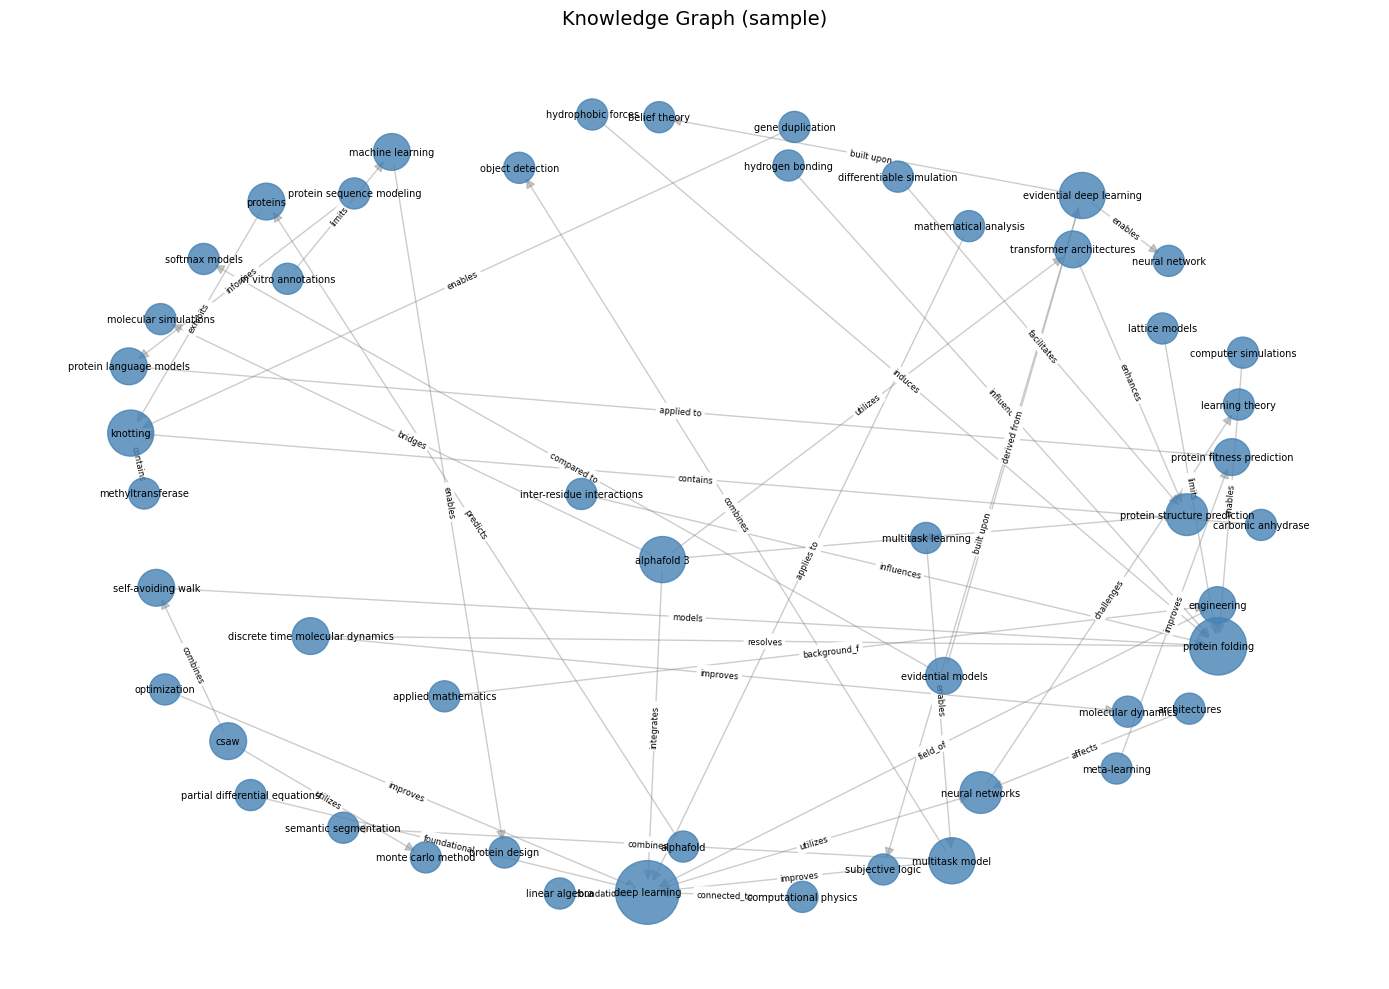

Full graph: 167 nodes, 158 edges


In [28]:
# Visualize the knowledge graph
pipeline.kg.visualize(max_nodes=50)

In [29]:
# Run the full pipeline: hypothesis → debate → falsify → insight
# ⏱️ Estimated time: 10-25 minutes for 5 hypotheses × 2 debate rounds
# Tip: Reduce CONFIG['num_hypotheses'] or CONFIG['debate_rounds'] to speed up

insights = pipeline.run(topic=TOPIC)


🎯 RUNNING PIPELINE ON TOPIC: "advances in protein folding and synthetic biology"

🔍 STAGE: Retrieval + Cross-Domain Exploration
  Retrieved 5 relevant chunks
  Graph context: 5 relationships

💡 STAGE: Hypothesis Generation
  ✅ Generated 5 hypotheses

⚔️  STAGE: Processing Hypothesis 1/5
  ----------------------------------------------
    💬 Debating: "Advances in protein folding will lead to breakthroughs in biomaterials, enabling..."
      Round 1/2...
      Round 2/2...
    🔬 Falsifying: "Advances in protein folding will lead to breakthroughs in biomaterials..."
  ✅ Insight generated (confidence: 0.40)

⚔️  STAGE: Processing Hypothesis 2/5
  ----------------------------------------------
    💬 Debating: "The integration of deep learning and physics-based molecular simulations will cr..."
      Round 1/2...
      Round 2/2...
    🔬 Falsifying: "The integration of deep learning and physics-based molecular simulatio..."
  ✅ Insight generated (confidence: 0.70)

⚔️  STAGE: Processing Hy

In [34]:
# Display all insights
print_all_insights(insights)


  SUMMARY TABLE — 5 STRATEGIC INSIGHTS
#    Confidence   Validity     Time Horizon    Headline
----------------------------------------------------------------------
1    40%          moderate     10-20 years     Breakthroughs in protein folding ar...
2    70%          moderate     10-20 years     The convergence of deep learning an...
3    55%          moderate     10-20 years     Investing in protein folding predic...
4    60%          moderate     10-20 years     Advances in synthetic biology hinge...
5    70%          moderate     20+ years       The convergence of environmental po...

  STRATEGIC INSIGHT #1

HEADLINE: Breakthroughs in protein folding are poised to revolutionize the construction industry with novel, sustainable biomaterials, transforming traditional supply chains and business models

HYPOTHESIS:
   Advances in protein folding will lead to breakthroughs in
   biomaterials, enabling the development of novel, sustainable
   materials that disrupt traditional supply c

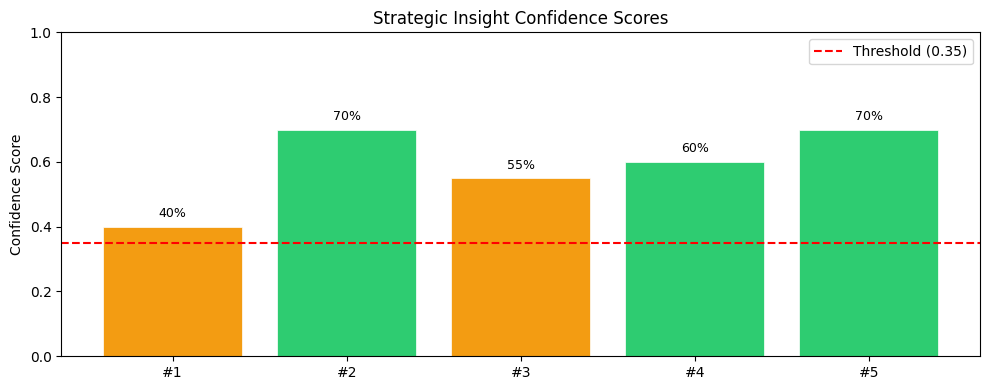

In [35]:
# Visualize confidence scores
plot_confidence_distribution(insights)

In [36]:
# Save to file
save_insights(insights, filename="strategic_insights.json")
print('\nDone! Download strategic_insights.json from the Files panel (left sidebar).')

Insights saved to strategic_insights.json

Done! Download strategic_insights.json from the Files panel (left sidebar).


---
## (Optional) Historical Backtesting

Test if the system can rediscover known implications from pre-2015 data.

In [37]:
def backtest_known_implication(
    known_implication: str,
    historical_topic: str,
    historical_queries: List[str],
    year_cutoff: int = 2015
):
    """
    Backtest: given a KNOWN strategic implication that emerged after year_cutoff,
    test if the pipeline can discover it from pre-cutoff papers alone.
    """
    print(f'\n🕰️  BACKTESTING against known implication:')
    print(f'   "{known_implication}"')
    print(f'   Using papers up to {year_cutoff}')

    # Create a separate pipeline for backtesting
    bt_pipeline = StrategicInsightPipeline()

    # Fetch papers and filter by year
    all_papers = []
    for q in historical_queries:
        papers = fetch_arxiv_papers(q, max_results=8)
        all_papers.extend(papers)

    historical_papers = [p for p in all_papers if p["year"] <= year_cutoff]
    print(f'   Papers within cutoff: {len(historical_papers)}')

    if not historical_papers:
        print('   ⚠️  No papers found within cutoff year. Try different queries.')
        return

    # Ingest historical papers directly
    chunks = papers_to_chunks(historical_papers)
    bt_pipeline.vector_store.add_chunks(chunks)
    bt_pipeline.kg.build_from_papers(historical_papers)
    bt_pipeline.papers_cache = historical_papers

    # Run pipeline
    discovered_insights = bt_pipeline.run(historical_topic)

    # Evaluate similarity to known implication
    if not discovered_insights:
        print('   ❌ No insights generated in backtest')
        return

    discovered_text = " ".join([
        ins.get("hypothesis", "") + " " +
        ins.get("strategic_insight", {}).get("headline", "")
        for ins in discovered_insights
    ])

    eval_prompt = f"""Rate how well these AI-generated strategic insights anticipate the following KNOWN historical implication.

KNOWN IMPLICATION: "{known_implication}"

AI-GENERATED INSIGHTS:
{discovered_text[:1500]}

Respond ONLY in this JSON format:
{{
  "anticipation_score": 0.0,
  "assessment": "[2-3 sentences: what did the AI get right, what did it miss?]",
  "best_matching_insight": "[Quote the insight that most closely anticipated the known implication]"
}}

Set anticipation_score between 0.0 (completely missed) and 1.0 (perfectly anticipated)."""

    raw = query_llm(eval_prompt, temperature=0.2)
    try:
        raw = re.sub(r"```json|```", "", raw).strip()
        result = json.loads(raw)
        print(f'\n   📊 Backtesting Result:')
        print(f'   Anticipation Score: {result["anticipation_score"]:.0%}')
        print(f'   Assessment: {result["assessment"]}')
        print(f'   Best Match: {result["best_matching_insight"]}')
    except Exception:
        print(f'   Raw evaluation: {raw[:500]}')


# Example backtest — uncomment to run (adds ~10-15 min)
# backtest_known_implication(
#     known_implication="CRISPR gene editing would enable precise agricultural modification, "
#                        "threatening existing GMO regulatory frameworks and creating new biosecurity risks",
#     historical_topic="CRISPR gene editing",
#     historical_queries=["CRISPR Cas9 gene editing", "bacterial immune system genome editing"],
#     year_cutoff=2014
# )

print('✅ Backtesting function ready (uncomment above to run)')

✅ Backtesting function ready (uncomment above to run)


---
## (Optional) Interactive Single-Query Mode

Quickly analyze a single hypothesis without running the full pipeline.

In [38]:
def quick_analyze(hypothesis_text: str):
    """
    Directly analyze a specific hypothesis using the pipeline's debate
    and abstraction machinery (skips ingestion — uses already-loaded data).
    """
    if not pipeline.papers_cache:
        print('⚠️  Run pipeline.ingest() first to load papers.')
        return

    print(f'\n🔬 Quick Analysis: "{hypothesis_text[:80]}..."')

    # Retrieve context
    retrieved = pipeline.vector_store.retrieve(hypothesis_text, top_k=3)
    context_str = "\n".join([c["text"][:300] for c in retrieved])

    hyp_dict = {
        "id": 99,
        "hypothesis": hypothesis_text,
        "domain_from": "user-specified",
        "domain_to": "strategic",
        "reasoning": "User-provided hypothesis",
        "time_horizon": "10-20 years"
    }

    # Debate
    debate_result = pipeline.debate.run_debate(hyp_dict, context_str, rounds=1)
    verdict = debate_result["verdict"]

    # Falsify
    falsification = pipeline.falsifier.test_hypothesis(hypothesis_text, verdict)

    # Abstract
    refined_hyp = {**hyp_dict, "refined_hypothesis": verdict.get("refined_hypothesis", hypothesis_text)}
    insight = pipeline.abstractor.abstract(refined_hyp, verdict, falsification)

    print_insight(insight)
    return insight


# Example — uncomment to run:
# quick_analyze(
#     "Advances in protein folding AI will enable decentralized bio-manufacturing, "
#     "reducing reliance on centralized pharmaceutical supply chains"
# )

print('✅ Quick analysis function ready')

✅ Quick analysis function ready


---

## 📋 System Architecture Summary

```
arXiv Papers
     │
     ▼
┌─────────────┐    ┌──────────────────┐
│ Vector Store │    │  Knowledge Graph │
│ (ChromaDB)  │    │  (NetworkX)      │
└──────┬──────┘    └────────┬─────────┘
       │                   │
       └─────────┬─────────┘
                 │  Retrieved context +
                 │  Graph relationships
                 ▼
        ┌─────────────────┐
        │   Hypothesis    │  (LLaMA 3.1 70B via Groq)
        │   Generator     │
        └────────┬────────┘
                 │
                 ▼
        ┌─────────────────┐
        │  Multi-Agent    │  Proposer vs Skeptic vs Expert
        │  Debate (×2)    │
        └────────┬────────┘
                 │
                 ▼
        ┌─────────────────┐
        │  Falsification  │  Counter-evidence retrieval
        │  Engine         │
        └────────┬────────┘
                 │  Filter low-confidence
                 ▼
        ┌─────────────────┐
        │  Strategic      │  Policy | Economic | Security
        │  Abstraction    │  + 2nd order effects
        └────────┬────────┘
                 │
                 ▼
        Strategic Insight Report
```

**Models used:** LLaMA 3.1 70B (Groq free tier) + all-MiniLM-L6-v2 (sentence embeddings)  
**Data source:** arXiv API (free, no key required)  
**Storage:** In-memory ChromaDB + NetworkX (no external DB needed)


  EVALUATION REPORT

Evaluating insight #1...
  Novelty:            4/5
  Plausibility:       4/5
  Strategic relevance:5/5
  Cross-domain depth: 5/5
  Falsifiability:     3/5
  OVERALL:            4.2/5
  Weakest aspect:     The weakest aspect of this insight is its falsifiability, as the hypothesis is somewhat vague and lacks specific, testable predictions that could be proven wrong.

Evaluating insight #2...
  Novelty:            3/5
  Plausibility:       4/5
  Strategic relevance:5/5
  Cross-domain depth: 4/5
  Falsifiability:     3/5
  OVERALL:            3.8/5
  Weakest aspect:     The insight's weakest aspect is its lack of novelty, as the potential of deep learning and molecular simulations in synthetic biology is already a well-explored area, making the hypothesis somewhat obvious to domain experts.

Evaluating insight #3...
  Novelty:            3/5
  Plausibility:       4/5
  Strategic relevance:5/5
  Cross-domain depth: 4/5
  Falsifiability:     3/5
  OVERALL:            3

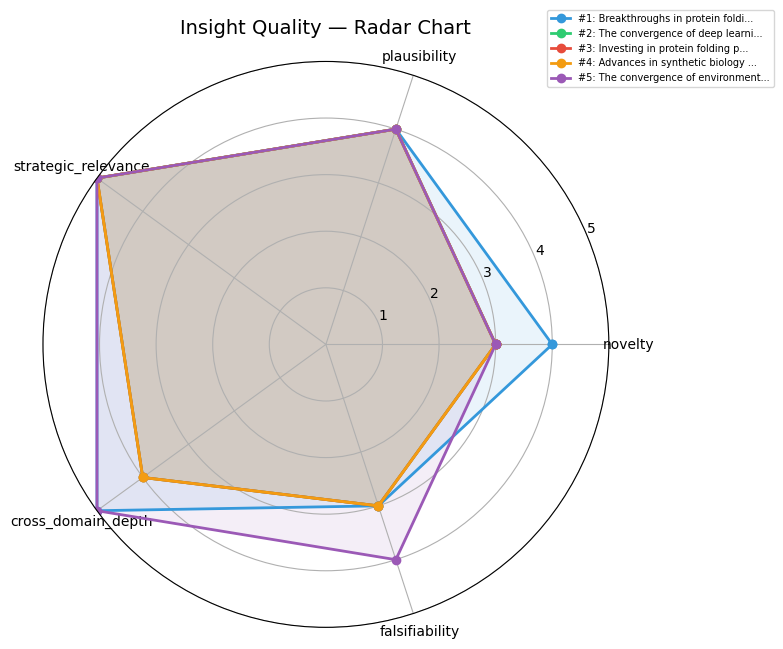

Insights saved to strategic_insights_evaluated.json


In [39]:
# Add this as a new notebook section: "EVALUATION FRAMEWORK"

EVALUATION_RUBRIC = {
    "novelty": {
        "description": "Would a domain expert already know this?",
        "scale": "1=obvious, 3=somewhat known, 5=genuinely surprising"
    },
    "plausibility": {
        "description": "Is the causal chain logically sound?",
        "scale": "1=implausible, 3=possible, 5=highly credible"
    },
    "strategic_relevance": {
        "description": "Does it matter for policy/security/economics?",
        "scale": "1=irrelevant, 3=somewhat relevant, 5=highly actionable"
    },
    "cross_domain_depth": {
        "description": "How many domains does it bridge?",
        "scale": "1=single domain, 3=two domains, 5=three or more"
    },
    "falsifiability": {
        "description": "Can it in principle be proven wrong?",
        "scale": "1=vague, 3=somewhat testable, 5=clearly falsifiable"
    }
}

def evaluate_insight_with_llm(insight: Dict) -> Dict:
    """
    Use LLM as an automated evaluator.
    Not a substitute for human eval but gives you scalable scores.
    """
    si = insight.get("strategic_insight", {})
    hypothesis = insight.get("hypothesis", "")
    headline = si.get("headline", "")

    prompt = f"""You are an expert evaluator of strategic foresight insights.
Score the following insight on each dimension.

INSIGHT:
Hypothesis: {hypothesis}
Headline: {headline}
Policy implication: {si.get("policy_implication", "")}
Economic impact: {si.get("economic_impact", "")}
Security risk: {si.get("security_risk", "")}

Score each dimension from 1-5:
- novelty: Would a domain expert already know this? (1=obvious, 5=genuinely surprising)
- plausibility: Is the causal chain logically sound? (1=implausible, 5=highly credible)
- strategic_relevance: Does it matter for policy/security/economics? (1=irrelevant, 5=highly actionable)
- cross_domain_depth: How many domains does it bridge? (1=single domain, 5=three or more)
- falsifiability: Can it be proven wrong? (1=vague, 5=clearly falsifiable)

Also write one sentence explaining the weakest aspect of this insight.

Respond ONLY in this JSON format:
{{
  "novelty": 0,
  "plausibility": 0,
  "strategic_relevance": 0,
  "cross_domain_depth": 0,
  "falsifiability": 0,
  "overall": 0,
  "weakest_aspect": "..."
}}"""

    raw = query_llm(prompt, temperature=0.2, max_tokens=300)
    try:
        raw = re.sub(r"```json|```", "", raw).strip()
        scores = json.loads(raw)
        scores["overall"] = round(sum([
            scores.get("novelty", 0),
            scores.get("plausibility", 0),
            scores.get("strategic_relevance", 0),
            scores.get("cross_domain_depth", 0),
            scores.get("falsifiability", 0)
        ]) / 5, 2)
        return scores
    except Exception:
        return {"novelty": 0, "plausibility": 0, "strategic_relevance": 0,
                "cross_domain_depth": 0, "falsifiability": 0, "overall": 0,
                "weakest_aspect": "Evaluation failed"}


def evaluate_all_insights(insights: List[Dict]) -> List[Dict]:
    """Evaluate all insights and print a report."""
    print("\n" + "=" * 60)
    print("  EVALUATION REPORT")
    print("=" * 60)

    results = []
    for i, insight in enumerate(insights, 1):
        print(f"\nEvaluating insight #{i}...")
        scores = evaluate_insight_with_llm(insight)
        insight["evaluation"] = scores
        results.append(scores)

        print(f"  Novelty:            {scores.get('novelty', 0)}/5")
        print(f"  Plausibility:       {scores.get('plausibility', 0)}/5")
        print(f"  Strategic relevance:{scores.get('strategic_relevance', 0)}/5")
        print(f"  Cross-domain depth: {scores.get('cross_domain_depth', 0)}/5")
        print(f"  Falsifiability:     {scores.get('falsifiability', 0)}/5")
        print(f"  OVERALL:            {scores.get('overall', 0)}/5")
        print(f"  Weakest aspect:     {scores.get('weakest_aspect', 'N/A')}")

    # Summary statistics
    if results:
        print("\n" + "-" * 60)
        print("AGGREGATE SCORES ACROSS ALL INSIGHTS:")
        for dim in ["novelty", "plausibility", "strategic_relevance", "cross_domain_depth", "falsifiability", "overall"]:
            avg = sum(r.get(dim, 0) for r in results) / len(results)
            print(f"  {dim:<25} avg: {avg:.2f}/5")

    return insights


def plot_evaluation_radar(insights: List[Dict]):
    """Radar chart comparing insights across evaluation dimensions."""
    import numpy as np

    dims = ["novelty", "plausibility", "strategic_relevance", "cross_domain_depth", "falsifiability"]
    labels = dims
    num_dims = len(dims)
    angles = [n / float(num_dims) * 2 * 3.14159 for n in range(num_dims)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"]

    for i, insight in enumerate(insights):
        scores = insight.get("evaluation", {})
        if not scores:
            continue
        values = [scores.get(d, 0) for d in dims]
        values += values[:1]
        label = f"#{i+1}: {insight.get('strategic_insight', {}).get('headline', '')[:30]}..."
        ax.plot(angles, values, "o-", linewidth=2,
                color=colors[i % len(colors)], label=label)
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=10)
    ax.set_ylim(0, 5)
    ax.set_title("Insight Quality — Radar Chart", size=14, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=7)
    plt.tight_layout()
    plt.show()


# Run it
insights = evaluate_all_insights(insights)
plot_evaluation_radar(insights)
save_insights(insights, "strategic_insights_evaluated.json")

In [40]:
# Add this as: "BACKTESTING — Historical Validation"

HISTORICAL_CASES = [
    {
        "name": "CRISPR → Biosecurity",
        "known_implication": "CRISPR gene editing would lower the barrier for creating biological weapons, enabling non-state actors to engineer pathogens, fundamentally changing biosecurity threat models",
        "historical_topic": "CRISPR Cas9 gene editing mechanisms",
        "historical_queries": [
            "CRISPR Cas9 bacterial immune system",
            "programmable genome editing nuclease",
        ],
        "year_cutoff": 2014,  # CRISPR was discovered ~2012, biosecurity concern emerged ~2015-2016
    },
    {
        "name": "Deep Learning → Medical Diagnosis Disruption",
        "known_implication": "Deep learning in medical imaging would threaten the economic model of radiology as a specialty, concentrating diagnostic capability in software and reducing demand for radiologists in developing countries first",
        "historical_topic": "convolutional neural networks image recognition",
        "historical_queries": [
            "deep learning convolutional neural network image classification",
            "neural network visual recognition features",
        ],
        "year_cutoff": 2014,  # AlexNet 2012, medical imaging disruption became clear ~2016-2017
    },
    {
        "name": "GPS → Precision Agriculture Power Shift",
        "known_implication": "GPS-enabled precision agriculture would increase productivity gaps between technologically advanced and developing agricultural nations, concentrating global food supply power",
        "historical_topic": "GPS satellite navigation positioning systems",
        "historical_queries": [
            "GPS global positioning satellite navigation accuracy",
            "satellite positioning civilian applications",
        ],
        "year_cutoff": 2000,
    },
]


def run_all_backtests(cases: List[Dict]):
    """Run backtesting on all historical cases and report results."""
    print("\n" + "=" * 60)
    print("  HISTORICAL BACKTESTING RESULTS")
    print("=" * 60)

    backtest_results = []

    for case in cases:
        print(f"\n\nCASE: {case['name']}")
        print(f"Known implication: {case['known_implication'][:100]}...")
        print(f"Year cutoff: {case['year_cutoff']}")
        print("-" * 50)

        # Build a fresh pipeline for this case
        bt = StrategicInsightPipeline()

        # Fetch and filter papers
        all_papers = []
        for q in case["historical_queries"]:
            papers = fetch_arxiv_papers(q, max_results=8)
            all_papers.extend(papers)

        historical_papers = [p for p in all_papers if p["year"] <= case["year_cutoff"]]
        print(f"Papers found within cutoff: {len(historical_papers)}")

        if not historical_papers:
            print("No papers found — skipping")
            continue

        # Ingest
        chunks = papers_to_chunks(historical_papers)
        bt.vector_store.add_chunks(chunks)
        bt.kg.build_from_papers(historical_papers)
        bt.papers_cache = historical_papers

        # Run pipeline
        discovered = bt.run(topic=case["historical_topic"])

        if not discovered:
            print("No insights generated")
            continue

        # Score against known implication
        discovered_text = " | ".join([
            ins.get("hypothesis", "") + " " +
            ins.get("strategic_insight", {}).get("headline", "")
            for ins in discovered
        ])

        eval_prompt = f"""Rate how well these AI-generated insights anticipate a known historical implication.

KNOWN IMPLICATION (emerged AFTER the cutoff year):
"{case['known_implication']}"

AI-GENERATED INSIGHTS (from papers BEFORE the cutoff):
{discovered_text[:2000]}

Respond ONLY in this JSON format:
{{
  "anticipation_score": 0.0,
  "what_it_got_right": "...",
  "what_it_missed": "...",
  "closest_insight": "..."
}}

Set anticipation_score: 0.0=completely missed, 0.5=partial, 1.0=perfectly anticipated."""

        raw = query_llm(eval_prompt, temperature=0.2)
        try:
            raw = re.sub(r"```json|```", "", raw).strip()
            result = json.loads(raw)
            result["case_name"] = case["name"]
            result["papers_used"] = len(historical_papers)
            backtest_results.append(result)

            print(f"Anticipation Score: {result['anticipation_score']:.0%}")
            print(f"Got right:  {result['what_it_got_right']}")
            print(f"Missed:     {result['what_it_missed']}")
            print(f"Best match: {result['closest_insight']}")

        except Exception as e:
            print(f"Evaluation failed: {e}")

    # Summary
    if backtest_results:
        avg_score = sum(r["anticipation_score"] for r in backtest_results) / len(backtest_results)
        print("\n" + "=" * 60)
        print(f"BACKTESTING SUMMARY")
        print(f"Cases tested:        {len(backtest_results)}")
        print(f"Average anticipation: {avg_score:.0%}")
        print("=" * 60)

    save_insights(backtest_results, "backtest_results.json")
    return backtest_results


# Run it — warning: this takes 30-60 min for all 3 cases
# Run one at a time if needed:
# run_all_backtests(HISTORICAL_CASES[:1])
backtest_results = run_all_backtests(HISTORICAL_CASES)


  HISTORICAL BACKTESTING RESULTS


CASE: CRISPR → Biosecurity
Known implication: CRISPR gene editing would lower the barrier for creating biological weapons, enabling non-state acto...
Year cutoff: 2014
--------------------------------------------------
🚀 Initializing Strategic Insight Pipeline...
  🗄️  Initializing VectorStore: scientific_knowledge


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ VectorStore ready
✅ Knowledge graph initialized
✅ Pipeline ready
  📡 Fetching 8 papers for: "CRISPR Cas9 bacterial immune system"
  ✅ Fetched 8 papers
  📡 Fetching 8 papers for: "programmable genome editing nuclease"
  ✅ Fetched 8 papers
Papers found within cutoff: 8
  📥 Adding 8 chunks to vector store...
  ✅ Vector store now has 8 chunks
  🔨 Building knowledge graph from 8 papers...


Building graph: 100%|██████████| 8/8 [00:16<00:00,  2.11s/it]


...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ VectorStore ready
✅ Knowledge graph initialized
✅ Pipeline ready
  📡 Fetching 8 papers for: "deep learning convolutional neural network image classification"
  ✅ Fetched 8 papers
  📡 Fetching 8 papers for: "neural network visual recognition features"
  ✅ Fetched 8 papers
Papers found within cutoff: 0
No papers found — skipping


CASE: GPS → Precision Agriculture Power Shift
Known implication: GPS-enabled precision agriculture would increase productivity gaps between technologically advanced ...
Year cutoff: 2000
--------------------------------------------------
🚀 Initializing Strategic Insight Pipeline...
  🗄️  Initializing VectorStore: scientific_knowledge


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ VectorStore ready
✅ Knowledge graph initialized
✅ Pipeline ready
  📡 Fetching 8 papers for: "GPS global positioning satellite navigation accuracy"
  ✅ Fetched 8 papers
  📡 Fetching 8 papers for: "satellite positioning civilian applications"
  ✅ Fetched 8 papers
Papers found within cutoff: 0
No papers found — skipping

BACKTESTING SUMMARY
Cases tested:        1
Average anticipation: 50%
Insights saved to backtest_results.json
